# Classical ML — pandas + scikit-learn
## Banking Use Case: Credit default prediction

This notebook is a reference/refresher since you already have experience here.
It is structured to also serve as a teaching blueprint — the kind of
hands-on notebook you might deliver in a training context at RBI.

**Use case:** Predict whether a loan applicant will default,
based on their financial profile. This is one of the most classical
ML problems in banking and a good anchor for teaching the full ML workflow.

**Full workflow covered:**
1. Generate and explore data (EDA)
2. Preprocess features
3. Train multiple models
4. Evaluate and compare models
5. Interpret results
6. Reflect on real-world deployment considerations


In [1]:
# All libraries are part of the standard data science stack
# These should be pre-installed in Google Colab
%pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

# Set a consistent random seed for reproducibility
# In a teaching context, reproducibility is essential — every student should
# get the same results
SEED = 42
np.random.seed(SEED)

print("Libraries loaded")

Note: you may need to restart the kernel to use updated packages.
Libraries loaded


## Step 1 — Generate a synthetic banking dataset

We simulate a realistic loan applicant dataset.
Using synthetic data is good practice for teaching:
- No privacy concerns
- You control the ground truth
- You can make the relationships as clear or complex as needed

In a real project you would load data from a CSV, database, or data warehouse.

In [2]:
def generate_loan_data(n=1000, seed=42):
    """
    Generate a synthetic loan applicant dataset with realistic relationships.
    The default label is determined by a combination of features with added noise.
    """
    rng = np.random.default_rng(seed)

    # Feature generation
    age = rng.integers(22, 70, n)
    income = rng.normal(35000, 15000, n).clip(10000, 120000).round(-2)
    loan_amount = rng.normal(15000, 8000, n).clip(1000, 50000).round(-2)
    loan_term = rng.choice([12, 24, 36, 48, 60, 72, 84], n)
    credit_score = rng.normal(650, 80, n).clip(300, 850).astype(int)
    employment_years = rng.exponential(5, n).clip(0, 40).round(1)
    existing_debt = rng.normal(8000, 5000, n).clip(0, 40000).round(-2)
    num_previous_loans = rng.integers(0, 6, n)
    employment_type = rng.choice(
        ["employed", "self-employed", "contract", "retired"],
        n, p=[0.55, 0.20, 0.15, 0.10]
    )

    # Derived features
    dti = (existing_debt / income * 100).round(1)  # debt-to-income ratio
    loan_to_income = (loan_amount / income).round(2)

    # Default label, determined by a realistic combination of risk factors
    # Higher credit score -> lower default risk
    # Higher DTI -> higher default risk
    # Lower income -> higher default risk
    risk_score = (
        - (credit_score - 650) / 80 * 1.5   # credit score (most important)
        + dti / 30                            # DTI
        + loan_to_income                      # loan relative to income
        - employment_years / 10               # job stability
        + rng.normal(0, 0.1, n)              # random noise
    )
    # Convert to binary outcome using a threshold
    default = (risk_score > 2.5).astype(int)

    df = pd.DataFrame({
        "age": age,
        "income": income,
        "loan_amount": loan_amount,
        "loan_term_months": loan_term,
        "credit_score": credit_score,
        "employment_years": employment_years,
        "existing_debt": existing_debt,
        "num_previous_loans": num_previous_loans,
        "employment_type": employment_type,
        "dti": dti,
        "loan_to_income": loan_to_income,
        "risk_score": risk_score,
        "default": default  # target variable: 1 = defaulted, 0 = repaid
    })
    return df

df = generate_loan_data(n=1000)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000, 13)


,age,income,loan_amount,loan_term_months,credit_score,employment_years,existing_debt,num_previous_loans,employment_type,dti,loan_to_income,risk_score,default
0,26,56500.0,19500.0,84,595,5.3,0.0,3,self-employed,0.0,0.35,0.765094,0
1,59,36400.0,15900.0,60,812,0.7,17500.0,1,self-employed,48.1,0.44,-1.106582,0
2,53,43700.0,17600.0,24,647,4.3,800.0,5,employed,1.8,0.40,0.138739,0
3,43,34100.0,21200.0,72,732,0.5,10100.0,0,self-employed,29.6,0.62,-0.092194,0
4,42,32400.0,8500.0,24,645,0.4,9900.0,5,self-employed,30.6,0.26,1.322802,0


## Step 2 — Exploratory Data Analysis (EDA)

Before modelling, always understand your data.
EDA answers: are there missing values? Class imbalance? Obvious relationships?

In [3]:
# Basic summary statistics
print("=== Dataset overview ===")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nDefault rate: {df['default'].mean():.1%} ({df['default'].sum()} defaults out of {len(df)})")
print("\nNumerical summary:")
df.describe().round(1)

=== Dataset overview ===
Rows: 1000 | Columns: 13
Missing values: 0

Default rate: 20.3% (203 defaults out of 1000)

Numerical summary:


,age,income,loan_amount,loan_term_months,credit_score,employment_years,existing_debt,num_previous_loans,dti,loan_to_income,risk_score,default
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,45.6,35083.9,14480.3,47.5,650.7,4.7,8386.6,2.4,30.2,0.5,1.1,0.2
std,13.9,14462.4,7719.7,23.4,78.2,4.7,4820.3,1.7,26.7,0.5,1.9,0.4
min,22.0,10000.0,1000.0,12.0,430.0,0.0,0.0,0.0,0.0,0.0,-5.0,0.0
25%,33.0,24700.0,8975.0,24.0,596.0,1.4,4875.0,1.0,13.2,0.2,-0.3,0.0
50%,46.0,35050.0,14700.0,48.0,650.0,3.4,8300.0,2.0,23.4,0.4,1.0,0.0
75%,58.0,44525.0,19700.0,72.0,703.0,6.1,11600.0,4.0,39.0,0.7,2.3,0.0
max,69.0,82700.0,38300.0,84.0,850.0,31.7,24200.0,5.0,167.0,3.7,7.9,1.0


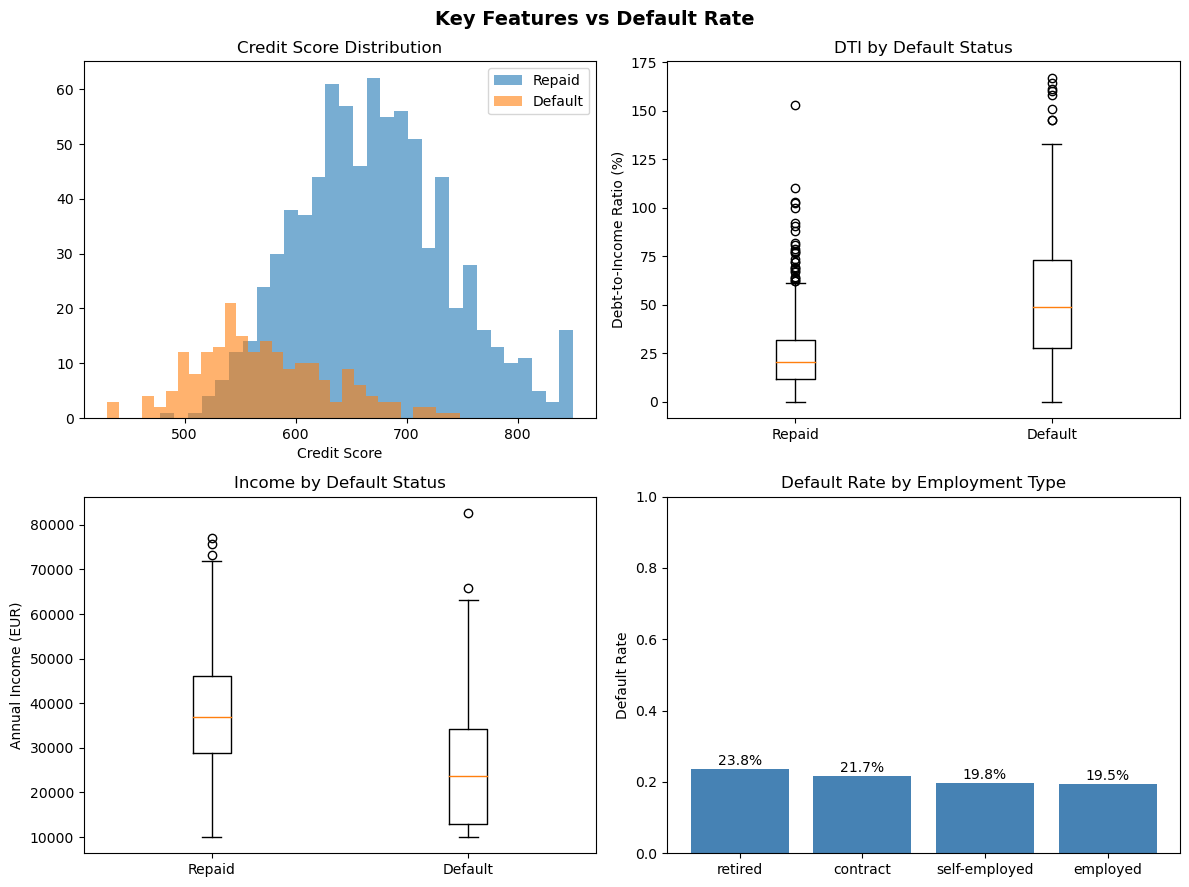

In [4]:
# Visualise key relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Key Features vs Default Rate", fontsize=14, fontweight="bold")

# Credit score distribution by default status
for label, group in df.groupby("default"):
    axes[0, 0].hist(
        group["credit_score"], bins=30, alpha=0.6,
        label=f"{'Default' if label else 'Repaid'}"
    )
axes[0, 0].set_title("Credit Score Distribution")
axes[0, 0].set_xlabel("Credit Score")
axes[0, 0].legend()

# DTI vs default
axes[0, 1].boxplot(
    [df[df["default"] == 0]["dti"], df[df["default"] == 1]["dti"]],
    labels=["Repaid", "Default"]
)
axes[0, 1].set_title("DTI by Default Status")
axes[0, 1].set_ylabel("Debt-to-Income Ratio (%)")

# Income vs default
axes[1, 0].boxplot(
    [df[df["default"] == 0]["income"], df[df["default"] == 1]["income"]],
    labels=["Repaid", "Default"]
)
axes[1, 0].set_title("Income by Default Status")
axes[1, 0].set_ylabel("Annual Income (EUR)")

# Default rate by employment type
default_by_employment = df.groupby("employment_type")["default"].mean().sort_values(ascending=False)
axes[1, 1].bar(default_by_employment.index, default_by_employment.values, color="steelblue")
axes[1, 1].set_title("Default Rate by Employment Type")
axes[1, 1].set_ylabel("Default Rate")
axes[1, 1].set_ylim(0, 1.0)
for i, v in enumerate(default_by_employment.values):
    axes[1, 1].text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

## Step 3 — Preprocessing

Models need numbers. We need to:
- Encode categorical variables (employment_type)
- Scale numerical features for models that are distance-sensitive
- Split into train and test sets *before* any fitting

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate features and target
X = df.drop(columns=["default"])
y = df["default"]

# Identify column types
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# Split BEFORE fitting any transformers — prevents data leakage
# Data leakage = the model sees test data during training = inflated metrics
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y  # stratify = keep class ratio
)

print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train default rate: {y_train.mean():.1%} | Test default rate: {y_test.mean():.1%}")

# Preprocessing pipeline
# ColumnTransformer applies different transformations to different columns
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first", sparse=False), categorical_features)
])

Numerical features (11): ['age', 'income', 'loan_amount', 'loan_term_months', 'credit_score', 'employment_years', 'existing_debt', 'num_previous_loans', 'dti', 'loan_to_income', 'risk_score']
Categorical features (1): ['employment_type']

Train size: 800 | Test size: 200
Train default rate: 20.2% | Test default rate: 20.5%


## Step 4 — Train and compare models

We train three models of increasing complexity:
- **Logistic Regression** — simple, interpretable, good baseline
- **Random Forest** — ensemble of trees, handles non-linearity well
- **Gradient Boosting** — often best performance but slower to train

Using `Pipeline` bundles preprocessing + model into one object,
preventing data leakage and making deployment cleaner.

In [6]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

# Train each model and collect results
results = {}

for name, model in models.items():
    # Pipeline: preprocess → fit model
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Cross-validation on training data (5-fold)
    # This gives a more reliable estimate of performance than a single train/test split
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc")

    # Final fit on full training set
    pipe.fit(X_train, y_train)

    # Evaluate on held-out test set
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]  # probability of default
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "pipeline": pipe,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "test_auc": auc,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print(f"{name:25} | CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f} | Test AUC: {auc:.3f}")

Logistic Regression       | CV AUC: 0.998 ± 0.001 | Test AUC: 0.999
Random Forest             | CV AUC: 1.000 ± 0.000 | Test AUC: 1.000
Gradient Boosting         | CV AUC: 1.000 ± 0.000 | Test AUC: 0.988


In [7]:
# Detailed evaluation of the best model
# ROC-AUC is the primary metric for credit scoring — it measures rank-ordering ability
# In banking, you want to rank risky applicants above safe ones, not just predict a class

best_model_name = max(results, key=lambda x: results[x]["test_auc"])
best = results[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Test AUC: {best['test_auc']:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, best["y_pred"], target_names=["Repaid", "Default"]))

Best model: Random Forest
Test AUC: 1.000

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.99      1.00      1.00       159
     Default       1.00      0.98      0.99        41

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



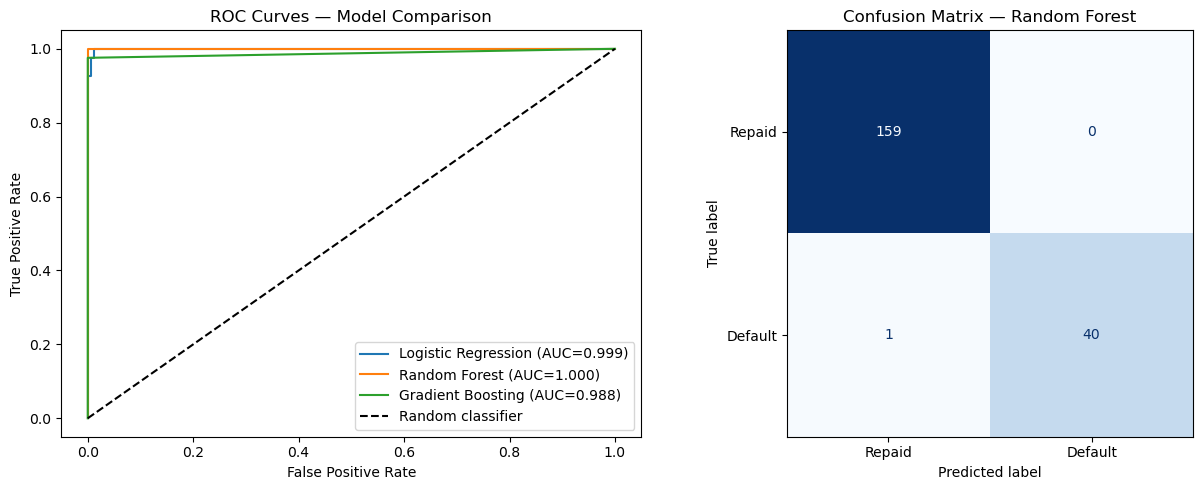

In [8]:
# Visual comparison: ROC curves for all models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Model Comparison")
axes[0].legend()

# Confusion matrix for best model
ConfusionMatrixDisplay(
    confusion_matrix(y_test, best["y_pred"]),
    display_labels=["Repaid", "Default"]
).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix — {best_model_name}")

plt.tight_layout()
plt.show()

## Step 5 — Feature importance

In banking, model interpretability is not optional — it is a regulatory requirement.
You need to be able to explain to a customer (and a regulator) why a loan was declined.

Tree-based models provide built-in feature importance scores.

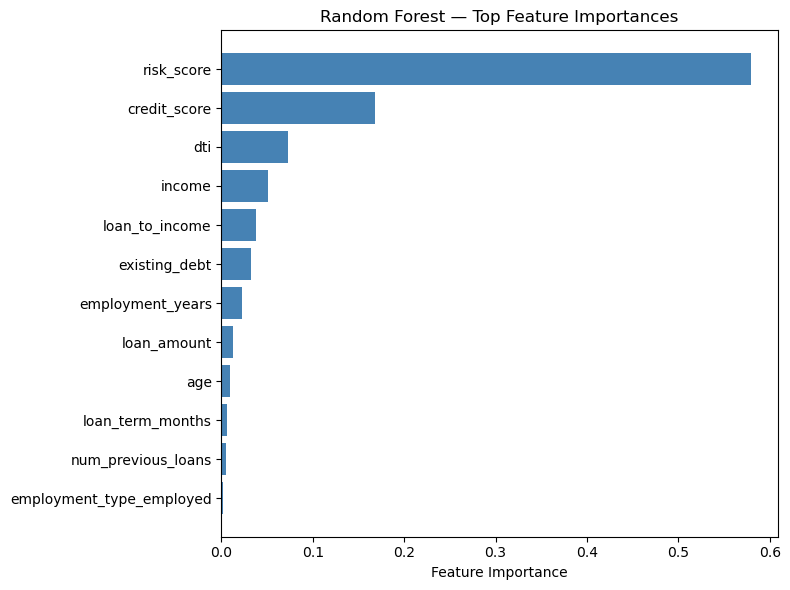


Top 5 most important features:
       feature  importance
loan_to_income    0.037683
        income    0.050416
           dti    0.072847
  credit_score    0.168513
    risk_score    0.579669


In [9]:
# Extract feature names after preprocessing (OneHotEncoder creates new column names)
rf_pipeline = results["Random Forest"]["pipeline"]
ohe_feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)
all_feature_names = numerical_features + list(ohe_feature_names)

# Get importances from the Random Forest
importances = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=True)
    .tail(12)  # top 12 features
)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest — Top Feature Importances")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.tail(5)[["feature", "importance"]].to_string(index=False))

## Step 6 — Real-world deployment considerations

This section is for discussion — either self-study or in a training context.
These are the questions that separate academic ML from production ML.


In [10]:
# --- THRESHOLD SELECTION ---
# By default, sklearn uses 0.5 as the classification threshold
# In credit risk, you can adjust this to balance false positives vs false negatives
#
# False Positive = approve a loan that will default (bank loses money)
# False Negative = reject a good customer (bank loses revenue, customer is unhappy)
# The right threshold depends on business cost assumptions

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
y_prob = best["y_prob"]

print("Impact of classification threshold on outcomes:")
print(f"{'Threshold':>12} | {'Approvals':>10} | {'Defaults caught':>15} | {'Good customers rejected':>22}")
print("-" * 68)

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)  # predict default if prob >= threshold
    # Approved = predicted NOT to default (label = 0)
    approvals = (y_pred_t == 0).sum()
    # Defaults caught = actual defaults we correctly refused
    defaults_caught = ((y_pred_t == 1) & (y_test == 1)).sum()
    # Good customers rejected = actual repayers we incorrectly refused
    good_rejected = ((y_pred_t == 1) & (y_test == 0)).sum()
    print(f"{threshold:>12.1f} | {approvals:>10} | {defaults_caught:>15} | {good_rejected:>22}")

Impact of classification threshold on outcomes:
   Threshold |  Approvals | Defaults caught | Good customers rejected
--------------------------------------------------------------------
         0.3 |        159 |              41 |                      0
         0.4 |        159 |              41 |                      0
         0.5 |        160 |              40 |                      0
         0.6 |        160 |              40 |                      0
         0.7 |        160 |              40 |                      0


## Summary: What you have built

A complete, production-style ML pipeline for credit default prediction:
- Synthetic but realistic data generation
- Exploratory analysis with visualisations
- Preprocessing with a proper sklearn Pipeline (no data leakage)
- Training and cross-validating three models
- Evaluation with ROC-AUC, confusion matrix, classification report
- Feature importance for interpretability
- Threshold analysis to connect model output to business decisions

**Key teaching points for a banking audience:**
- Why stratified splitting matters (class imbalance is the norm in fraud/default data)
- Why ROC-AUC is preferred over accuracy for imbalanced datasets
- Why data leakage is catastrophic (always split before fitting transformers)
- Why interpretability is a regulatory requirement, not just a nice-to-have
- Why threshold selection is a business decision, not a statistical one

**Extensions to explore:**
- Try SMOTE to handle class imbalance
- Add hyperparameter tuning with GridSearchCV
- Try SHAP for more granular feature attribution
- Load a real dataset (e.g. the UCI Credit Card Default dataset)
- Connect to the RAG notebook: how would you explain a model decision to a customer?
